# Face Mask Detection - Deep Learning Midterm
**Istanbul Topkapı University**  
Using pre-trained DenseNet121 and MobileNetV1 models

## 1. Install & Import Libraries

In [ ]:
# Uncomment to install if needed
# !pip install kaggle tensorflow scikit-learn matplotlib seaborn pandas numpy

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_curve, auc, accuracy_score,
                             precision_score, recall_score, f1_score)

import tensorflow as tf
from tensorflow.keras.applications import DenseNet121, MobileNet # type: ignore
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout # type: ignore
from tensorflow.keras.models import Model # type: ignore
from tensorflow.keras.preprocessing.image import ImageDataGenerator # type: ignore
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint # type: ignore
from tensorflow.keras.optimizers import Adam # type: ignore

print('TensorFlow version:', tf.__version__)
print('GPUs available:', tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.21.0
GPUs available: []


## 2. Dataset

In [ ]:
#Data Kaggle'dan manuel olarak indirilip unzip edilerek eklenmistir.
DATASET_PATH = 'data'

# Verify structure
for root, dirs, files in os.walk(DATASET_PATH):
    level = root.replace(DATASET_PATH, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    if level < 2:
        subindent = ' ' * 2 * (level + 1)
        print(f'{subindent}{len(files)} files')

data/
  0 files
  without_mask/
    3828 files
  with_mask/
    3725 files


## 3. Load & Explore the Dataset

In [3]:
# Build file paths and labels
image_paths = []
labels = []

class_names = sorted(os.listdir(DATASET_PATH))
print('Classes found:', class_names)

for label_idx, class_name in enumerate(class_names):
    class_folder = os.path.join(DATASET_PATH, class_name)
    if not os.path.isdir(class_folder):
        continue
    for fname in os.listdir(class_folder):
        if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
            image_paths.append(os.path.join(class_folder, fname))
            labels.append(label_idx)

image_paths = np.array(image_paths)
labels = np.array(labels)

print(f'\nTotal images: {len(image_paths)}')
for i, cls in enumerate(class_names):
    print(f'  {cls}: {np.sum(labels == i)} images')

Classes found: ['with_mask', 'without_mask']

Total images: 7553
  with_mask: 3725 images
  without_mask: 3828 images


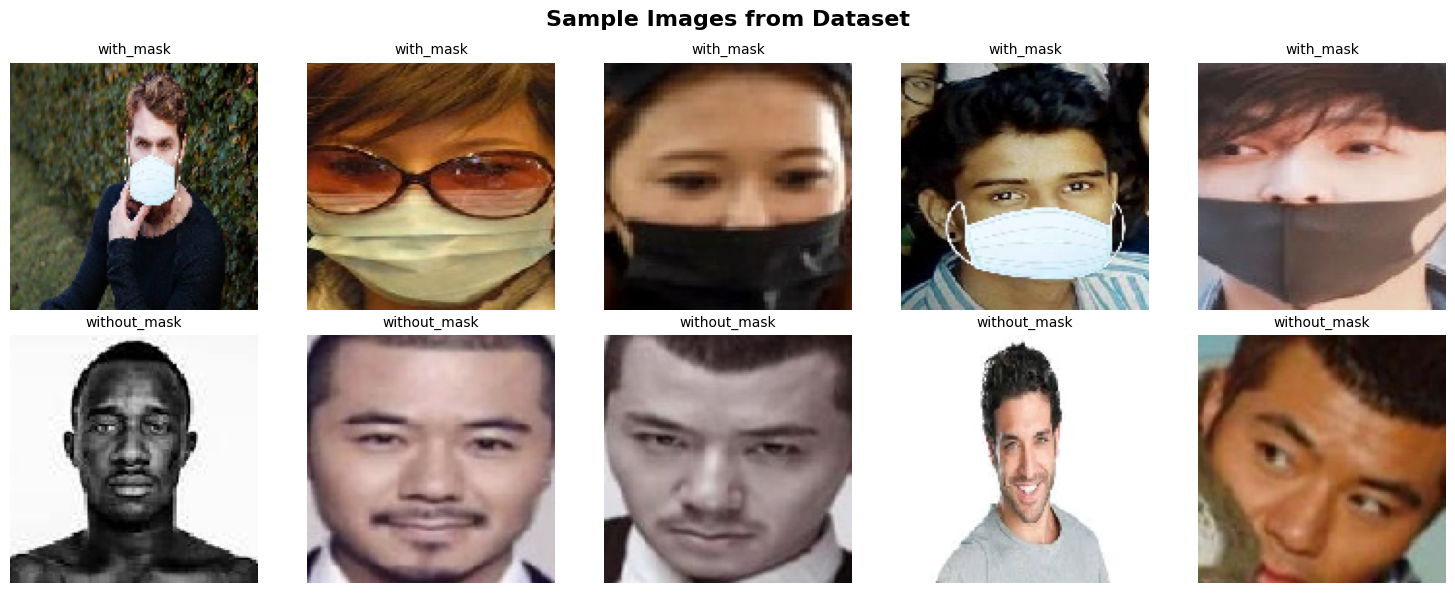

In [ ]:
# Visualize sample images
from tensorflow.keras.preprocessing.image import load_img # type: ignore

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle('Sample Images from Dataset', fontsize=16, fontweight='bold')

for class_idx, class_name in enumerate(class_names):
    class_images = image_paths[labels == class_idx][:5]
    for i, img_path in enumerate(class_images):
        img = load_img(img_path, target_size=(128, 128))
        axes[class_idx, i].imshow(img)
        axes[class_idx, i].set_title(class_name, fontsize=10)
        axes[class_idx, i].axis('off')

plt.tight_layout()
plt.savefig('sample_images.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Train / Validation / Test Split

In [ ]:
# Step 1: 20% as test set
X_trainval, X_test, y_trainval, y_test = train_test_split(
    image_paths, labels,
    test_size=0.20,
    random_state=42,
    stratify=labels
)

# Step 2: Split remaining 80% into 80% train / 20% validation
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval,
    test_size=0.20,
    random_state=42,
    stratify=y_trainval
)

print(f'Training samples  : {len(X_train)}')
print(f'Validation samples: {len(X_val)}')
print(f'Test samples      : {len(X_test)}')
print(f'\nTotal             : {len(X_train) + len(X_val) + len(X_test)}')

Training samples  : 4833
Validation samples: 1209
Test samples      : 1511

Total             : 7553


## 5. Data Generators with Augmentation

In [ ]:
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
NUM_CLASSES = 2

# Helper: build a DataFrame for flow_from_dataframe
def make_df(paths, lbls):
    return pd.DataFrame({
        'filepath': paths,
        'label': [class_names[l] for l in lbls]
    })

train_df = make_df(X_train, y_train)
val_df   = make_df(X_val,   y_val)
test_df  = make_df(X_test,  y_test)

# Augmented generator for training
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

# No augmentation for validation/test, only rescaling
# Normalize ediyoruz piksel degerlerini ayni olsun diye 

val_test_datagen = ImageDataGenerator(rescale=1.0 / 255)

# Batching
train_gen = train_datagen.flow_from_dataframe(
    train_df, x_col='filepath', y_col='label',
    target_size=IMAGE_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=True, seed=42
)

val_gen = val_test_datagen.flow_from_dataframe(
    val_df, x_col='filepath', y_col='label',
    target_size=IMAGE_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False
)

test_gen = val_test_datagen.flow_from_dataframe(
    test_df, x_col='filepath', y_col='label',
    target_size=IMAGE_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False
)

print('Class indices:', train_gen.class_indices)

Found 4833 validated image filenames belonging to 2 classes.
Found 1209 validated image filenames belonging to 2 classes.
Found 1511 validated image filenames belonging to 2 classes.
Class indices: {'with_mask': 0, 'without_mask': 1}


## 6. Model Building

In [ ]:
def build_model(base_name='densenet'):
    """Build a transfer-learning model with custom classification head."""
    if base_name == 'densenet':
        base_model = DenseNet121(
            weights='imagenet',
            include_top=False,
            input_shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3)
        )
    else:  # mobilenet
        base_model = MobileNet(
            weights='imagenet',
            include_top=False,
            input_shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3)
        )

    # Freeze base model weights
    # Modeller pre-trained ve fine tune yapmiyoruz
    base_model.trainable = False

    # Model olusturma
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.5)(x)
    x = Dense(256, activation='relu')(x)
    x = Dense(256, activation='relu')(x)
    x = Dense(128, activation='relu')(x)
    x = Dense(64,  activation='relu')(x)
    predictions = Dense(NUM_CLASSES, activation='softmax')(x)

    model = Model(inputs=base_model.input, outputs=predictions)
    return model

## 7. Train DenseNet121

In [ ]:
# --- Build & compile ---
densenet_model = build_model('densenet')

densenet_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

#densenet_model.summary()
# Summary cok uzun oldugu icin clear ettim, kontrol ettikten sonra.

In [9]:
# --- Callbacks ---
callbacks_densenet = [
    EarlyStopping(
        monitor='val_loss',
        patience=25,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.1,
        patience=5,
        min_lr=1e-7,
        verbose=1
    ),
    ModelCheckpoint(
        'best_densenet.weights.h5',
        monitor='val_loss',
        save_best_only=True,
        save_weights_only=True,
        verbose=0
    )
]

# --- Train ---
history_densenet = densenet_model.fit(
    train_gen,
    epochs=100,
    validation_data=val_gen,
    callbacks=callbacks_densenet,
    verbose=1
)

Epoch 1/100
152/152 ━━━━━━━━━━━━━━━━━━━━ 121s 755ms/step - accuracy: 0.9650 - loss: 0.0994 - val_accuracy: 0.9694 - val_loss: 0.0997 - learning_rate: 0.0010
Epoch 2/100
152/152 ━━━━━━━━━━━━━━━━━━━━ 108s 707ms/step - accuracy: 0.9739 - loss: 0.0745 - val_accuracy: 0.9859 - val_loss: 0.0403 - learning_rate: 0.0010
Epoch 3/100
152/152 ━━━━━━━━━━━━━━━━━━━━ 110s 722ms/step - accuracy: 0.9826 - loss: 0.0543 - val_accuracy: 0.9917 - val_loss: 0.0178 - learning_rate: 0.0010
Epoch 4/100
152/152 ━━━━━━━━━━━━━━━━━━━━ 108s 713ms/step - accuracy: 0.9803 - loss: 0.0583 - val_accuracy: 0.9868 - val_loss: 0.0257 - learning_rate: 0.0010
Epoch 5/100
152/152 ━━━━━━━━━━━━━━━━━━━━ 108s 712ms/step - accuracy: 0.9830 - loss: 0.0519 - val_accuracy: 0.9868 - val_loss: 0.0318 - learning_rate: 0.0010
Epoch 6/100
152/152 ━━━━━━━━━━━━━━━━━━━━ 108s 708ms/step - accuracy: 0.9861 - loss: 0.0471 - val_accuracy: 0.9950 - val_loss: 0.0217 - learning_rate: 0.0010
Epoch 7/100
152/152 ━━━━━━━━━━━━━━━━━━━━ 108s 710ms/step -

## 8. Train MobileNetV1

In [10]:
mobilenet_model = build_model('mobilenet')

mobilenet_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_mobilenet = [
    EarlyStopping(
        monitor='val_loss',
        patience=25,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.1,
        patience=5,
        min_lr=1e-7,
        verbose=1
    ),
    ModelCheckpoint(
        'best_mobilenet.weights.h5',
        monitor='val_loss',
        save_best_only=True,
        save_weights_only=True,
        verbose=0
    )
]

history_mobilenet = mobilenet_model.fit(
    train_gen,
    epochs=100,
    validation_data=val_gen,
    callbacks=callbacks_mobilenet,
    verbose=1
)

17225924/17225924 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Epoch 1/100
152/152 ━━━━━━━━━━━━━━━━━━━━ 50s 320ms/step - accuracy: 0.9605 - loss: 0.1120 - val_accuracy: 0.9744 - val_loss: 0.0642 - learning_rate: 0.0010
Epoch 2/100
152/152 ━━━━━━━━━━━━━━━━━━━━ 48s 315ms/step - accuracy: 0.9822 - loss: 0.0475 - val_accuracy: 0.9917 - val_loss: 0.0178 - learning_rate: 0.0010
Epoch 3/100
152/152 ━━━━━━━━━━━━━━━━━━━━ 49s 321ms/step - accuracy: 0.9845 - loss: 0.0414 - val_accuracy: 0.9967 - val_loss: 0.0152 - learning_rate: 0.0010
Epoch 4/100
152/152 ━━━━━━━━━━━━━━━━━━━━ 49s 325ms/step - accuracy: 0.9868 - loss: 0.0346 - val_accuracy: 0.9959 - val_loss: 0.0131 - learning_rate: 0.0010
Epoch 5/100
152/152 ━━━━━━━━━━━━━━━━━━━━ 49s 324ms/step - accuracy: 0.9874 - loss: 0.0339 - val_accuracy: 0.9983 - val_loss: 0.0095 - learning_rate: 0.0010
Epoch 6/100
152/152 ━━━━━━━━━━━━━━━━━━━━ 47s 306ms/step - accuracy: 0.9859 - loss: 0.0403 - val_accuracy: 0.9892 - val_loss: 0.0208 - learning_rate: 0.0010
Epoch 7/100
1

## 9. Training Curves

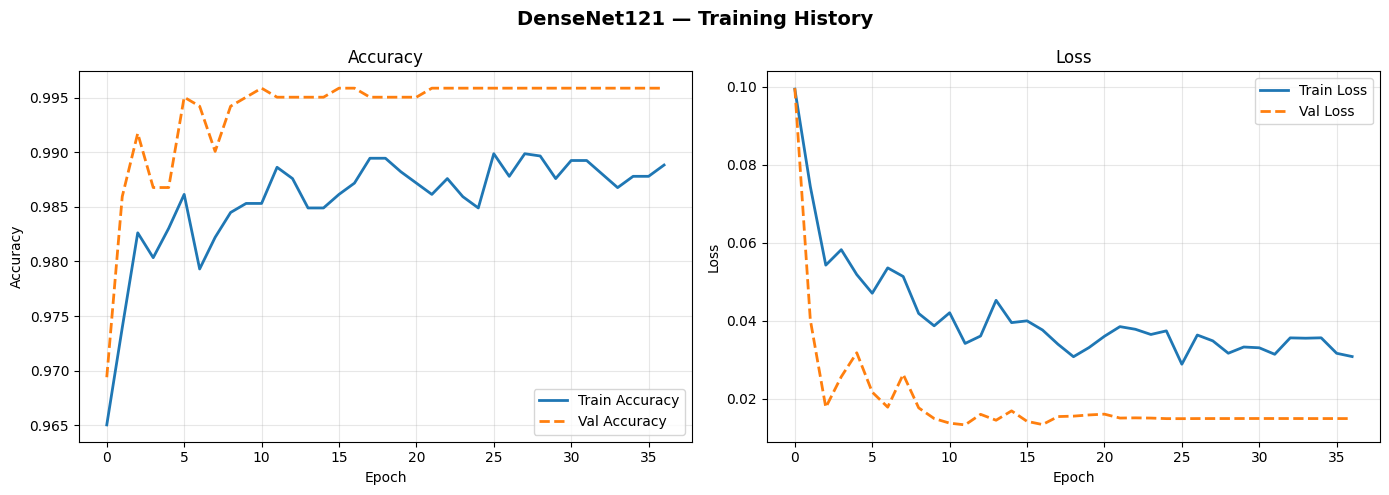

Saved: history_densenet121.png


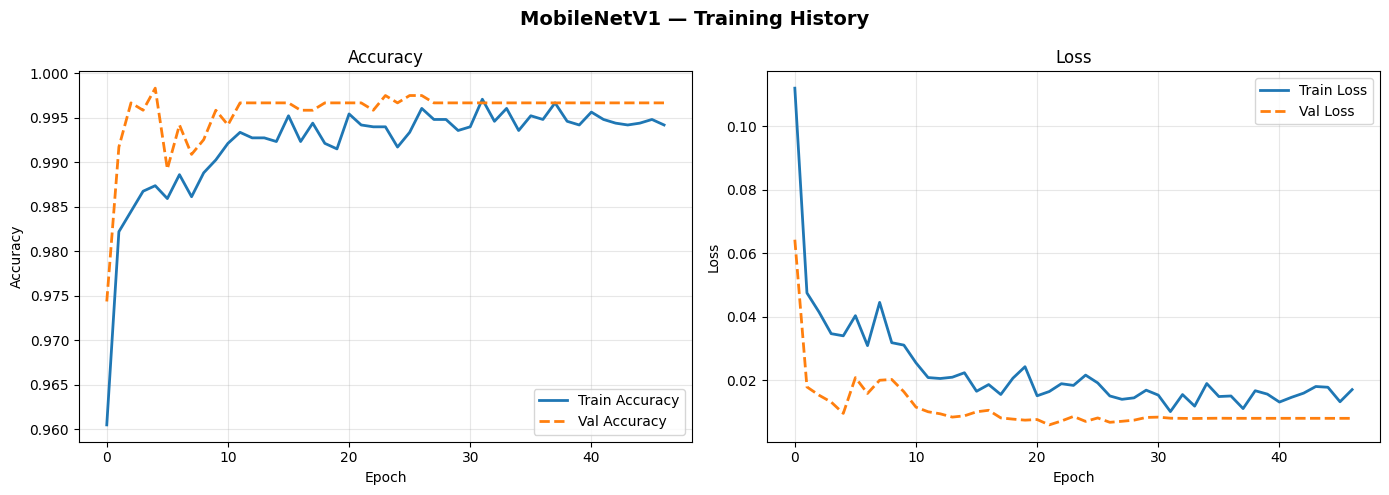

Saved: history_mobilenetv1.png


In [11]:
def plot_history(history, model_name):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'{model_name} — Training History', fontsize=14, fontweight='bold')

    # Accuracy
    axes[0].plot(history.history['accuracy'],     label='Train Accuracy', linewidth=2)
    axes[0].plot(history.history['val_accuracy'], label='Val Accuracy',   linewidth=2, linestyle='--')
    axes[0].set_title('Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Loss
    axes[1].plot(history.history['loss'],     label='Train Loss', linewidth=2)
    axes[1].plot(history.history['val_loss'], label='Val Loss',   linewidth=2, linestyle='--')
    axes[1].set_title('Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    fname = f'history_{model_name.lower().replace(" ", "_")}.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {fname}')

plot_history(history_densenet,  'DenseNet121')
plot_history(history_mobilenet, 'MobileNetV1')

## 10. Evaluation on Test Set

In [12]:
def evaluate_model(model, weights_path, test_generator, model_name):
    """Load best weights, predict on test set, compute all required metrics."""
    # Load best saved weights
    model.load_weights(weights_path)

    test_generator.reset()
    y_prob = model.predict(test_generator, verbose=1)

    y_pred = np.argmax(y_prob, axis=1)
    y_true = test_generator.classes
    y_prob_pos = y_prob[:, 1]  # probability of positive class

    # --- Metrics ---
    acc       = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='binary')
    recall    = recall_score(y_true, y_pred, average='binary')    # sensitivity
    f1        = f1_score(y_true, y_pred, average='binary')

    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn + fp)

    fpr, tpr, _ = roc_curve(y_true, y_prob_pos)
    roc_auc     = auc(fpr, tpr)

    print(f'\n========== {model_name} Test Results ==========')
    print(f'  Accuracy    : {acc:.4f}')
    print(f'  Precision   : {precision:.4f}')
    print(f'  Recall      : {recall:.4f}')
    print(f'  Specificity : {specificity:.4f}')
    print(f'  F1-Score    : {f1:.4f}')
    print(f'  AUC         : {roc_auc:.4f}')
    print(f'\nClassification Report:\n')
    print(classification_report(y_true, y_pred, target_names=class_names))

    return {
        'model_name': model_name,
        'y_true': y_true, 'y_pred': y_pred, 'y_prob': y_prob_pos,
        'accuracy': acc, 'precision': precision, 'recall': recall,
        'specificity': specificity, 'f1': f1, 'auc': roc_auc,
        'fpr': fpr, 'tpr': tpr, 'cm': cm
    }

In [13]:
results_densenet  = evaluate_model(densenet_model,  'best_densenet.weights.h5',  test_gen, 'DenseNet121')
results_mobilenet = evaluate_model(mobilenet_model, 'best_mobilenet.weights.h5', test_gen, 'MobileNetV1')

48/48 ━━━━━━━━━━━━━━━━━━━━ 32s 620ms/step

========== DenseNet121 Test Results ==========
  Accuracy    : 0.9967
  Precision   : 0.9987
  Recall      : 0.9948
  Specificity : 0.9987
  F1-Score    : 0.9967
  AUC         : 0.9999

Classification Report:

              precision    recall  f1-score   support

   with_mask       0.99      1.00      1.00       745
without_mask       1.00      0.99      1.00       766

    accuracy                           1.00      1511
   macro avg       1.00      1.00      1.00      1511
weighted avg       1.00      1.00      1.00      1511

48/48 ━━━━━━━━━━━━━━━━━━━━ 8s 163ms/step

========== MobileNetV1 Test Results ==========
  Accuracy    : 0.9980
  Precision   : 0.9974
  Recall      : 0.9987
  Specificity : 0.9973
  F1-Score    : 0.9980
  AUC         : 1.0000

Classification Report:

              precision    recall  f1-score   support

   with_mask       1.00      1.00      1.00       745
without_mask       1.00      1.00      1.00       766

    

## 11. Confusion Matrices

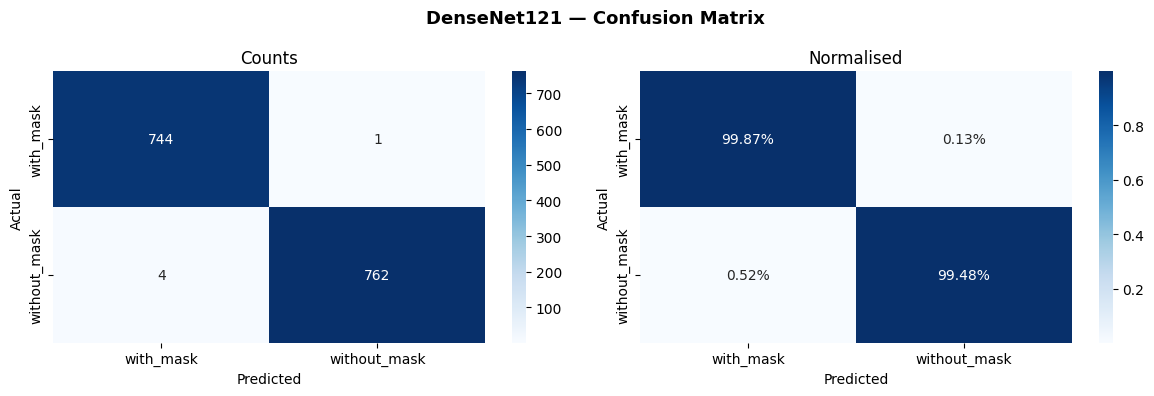

Saved: confusion_matrix_densenet121.png


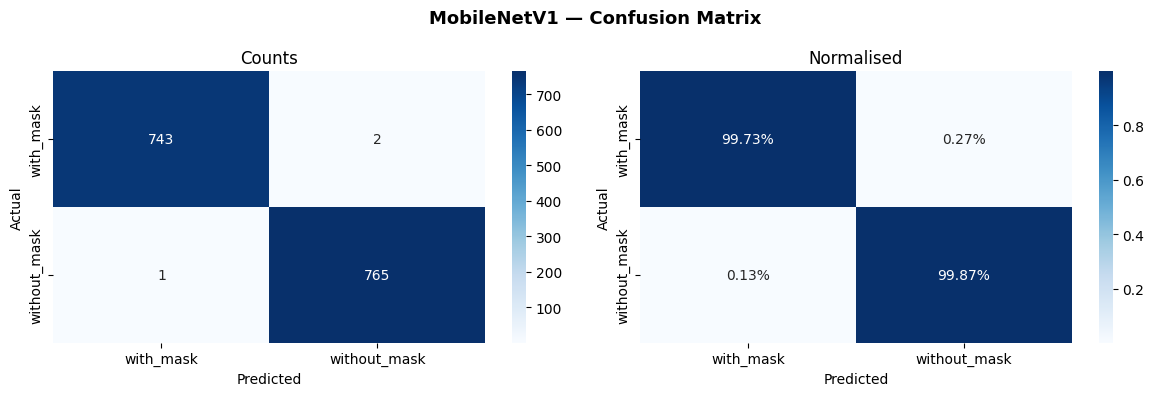

Saved: confusion_matrix_mobilenetv1.png


In [14]:
def plot_confusion_matrix(results):
    cm = results['cm']
    name = results['model_name']

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(f'{name} — Confusion Matrix', fontsize=13, fontweight='bold')

    # Raw counts
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=axes[0])
    axes[0].set_title('Counts')
    axes[0].set_xlabel('Predicted')
    axes[0].set_ylabel('Actual')

    # Normalised
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=axes[1])
    axes[1].set_title('Normalised')
    axes[1].set_xlabel('Predicted')
    axes[1].set_ylabel('Actual')

    plt.tight_layout()
    fname = f'confusion_matrix_{name.lower().replace(" ", "_")}.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {fname}')

plot_confusion_matrix(results_densenet)
plot_confusion_matrix(results_mobilenet)

## 12. ROC Curves

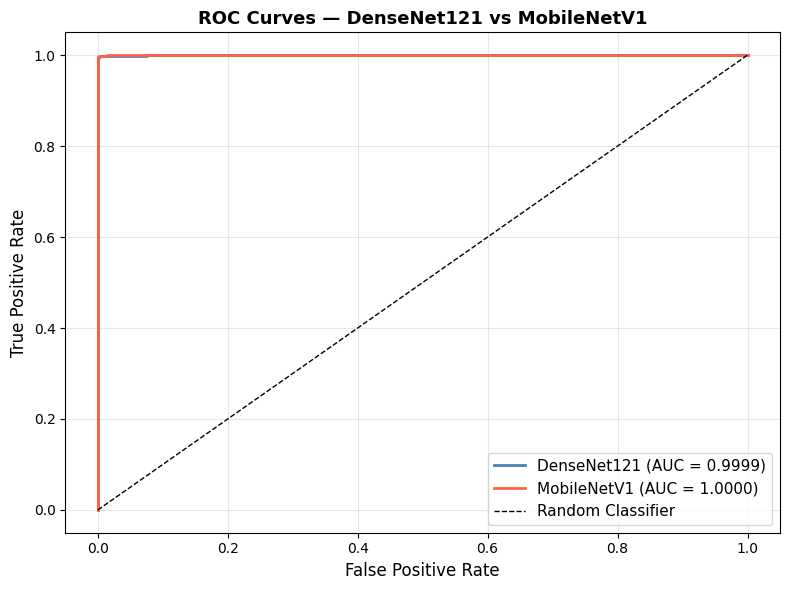

Saved: roc_curves.png


In [15]:
plt.figure(figsize=(8, 6))

for res, color in [(results_densenet, 'steelblue'), (results_mobilenet, 'tomato')]:
    plt.plot(
        res['fpr'], res['tpr'],
        color=color, linewidth=2,
        label=f"{res['model_name']} (AUC = {res['auc']:.4f})"
    )

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves — DenseNet121 vs MobileNetV1', fontsize=13, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: roc_curves.png')

## 13. Model Comparison Summary

              Metric  DenseNet121  MobileNetV1
            Accuracy       0.9967       0.9980
           Precision       0.9987       0.9974
Recall (Sensitivity)       0.9948       0.9987
         Specificity       0.9987       0.9973
            F1-Score       0.9967       0.9980
                 AUC       0.9999       1.0000


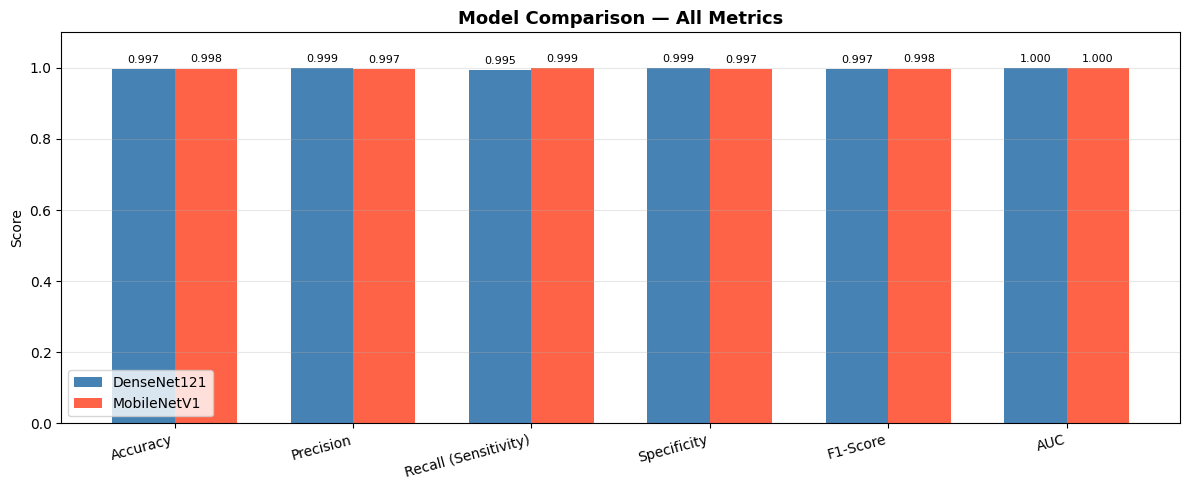

Saved: model_comparison.png


In [16]:
metrics = ['accuracy', 'precision', 'recall', 'specificity', 'f1', 'auc']
metric_labels = ['Accuracy', 'Precision', 'Recall (Sensitivity)', 'Specificity', 'F1-Score', 'AUC']

summary_df = pd.DataFrame({
    'Metric': metric_labels,
    'DenseNet121': [round(results_densenet[m], 4)  for m in metrics],
    'MobileNetV1': [round(results_mobilenet[m], 4) for m in metrics],
})

print(summary_df.to_string(index=False))

# Bar chart comparison
x = np.arange(len(metric_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
bars1 = ax.bar(x - width/2, summary_df['DenseNet121'], width, label='DenseNet121', color='steelblue')
bars2 = ax.bar(x + width/2, summary_df['MobileNetV1'], width, label='MobileNetV1', color='tomato')

ax.set_ylabel('Score')
ax.set_title('Model Comparison — All Metrics', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metric_labels, rotation=15, ha='right')
ax.set_ylim(0, 1.1)
ax.legend()
ax.grid(True, axis='y', alpha=0.3)

for bar in bars1:
    ax.annotate(f'{bar.get_height():.3f}',
                xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                xytext=(0, 3), textcoords='offset points', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    ax.annotate(f'{bar.get_height():.3f}',
                xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                xytext=(0, 3), textcoords='offset points', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: model_comparison.png')